In [ ]:
 # agbado study analysis 

In [ ]:
import py

In [1]:
import pandas as pd        # data handling
import numpy as np         # numerical operations
import scipy.stats as stats # inferential statistics
import matplotlib.pyplot as plt  # plots

In [2]:
pwd

'C:\\Users\\ajayi'

In [3]:
cd Desktop

C:\Users\ajayi\Desktop


In [4]:
cd python_data_analysis

C:\Users\ajayi\Desktop\python_data_analysis


In [5]:
pwd

'C:\\Users\\ajayi\\Desktop\\python_data_analysis'

In [6]:
data = pd.read_excel("Mass_screening_agbado_april2026_analyze.xlsx")
 

In [7]:
data.head() 
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 55 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Gender                                          193 non-null    object 
 1   GenderLR                                        193 non-null    int64  
 2   Age                                             193 non-null    object 
 3   HLFE                                            165 non-null    object 
 4   Religion                                        193 non-null    object 
 5   Occupa                                          192 non-null    object 
 6   occupation                                      193 non-null    object 
 7   Marital_status                                  193 non-null    object 
 8   Family_type                                     175 non-null    object 
 9   Tribe                                      

In [14]:
desc_continuous = data[['Gender', 'Age', 'HLFE', 'Religion', 'Occupa', 'occupation', 'Marital_status', 'Family_type', 'Tribe', 'Prior_glucose_test', 'Ever_told_to_have_Diabetes', 'DM_duration', 'Medication', 'Prior_bp_check', 'Prior_told_of_htn', 'Duration_of_htn', 'Drugs_for_htn' ,'history_of_stroke_heart_disease_kidney_disease', 'long_term_medication', 'Frequent_urination', 'Excessive_thirst', 'Unexplained_weight_loss', 'Blurred_vision', 'Slow_healing_cuts_infections', 'Numbness_tingling_hands_feets', 'Frequent_headaches', 'Dizziness', 'Shortness_of_breath', 'legs_ankle_swelling', 'Family_history_of_Diabetes', 'Family_history_of_htn', 'smoke_tobacco', 'Alcohol_frequency_per_week', 'alcohol', 'Physical_activity', 'Typical_daily_fruits_vegetables_portion', 'add_salts_to_cooked_food', 'high_blood_sugar_during_pregnancy', 'BMI', 'SBP', 'DBP', 'RBG']]


array([[<Axes: title={'center': 'BMI'}>, <Axes: title={'center': 'SBP'}>],
       [<Axes: title={'center': 'DBP'}>, <Axes: title={'center': 'RBG'}>]],
      dtype=object)

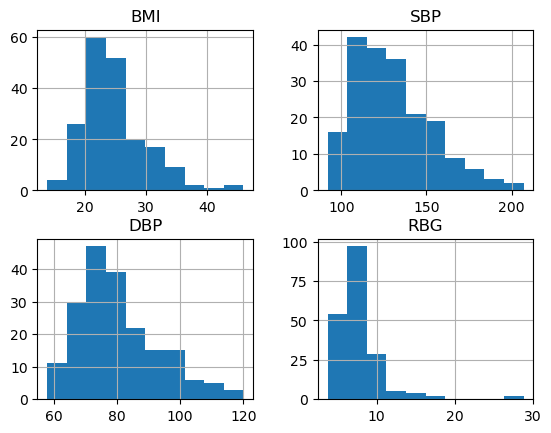

In [11]:
data.hist()

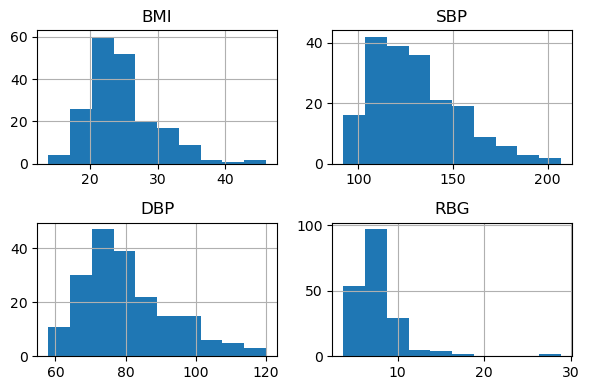

In [12]:
# This tells Pandas to plot histograms for every numeric column in that selection
data[['Age', 'BMI', 'SBP', 'DBP', 'RBG']].hist(figsize=(6, 4))

plt.tight_layout() # This keeps the labels from overlapping
plt.show()

In [13]:
# This strips spaces
data.columns = data.columns.str.strip()

In [14]:
# This captures all columns with 'object' (strings) or 'category' types
cat_data = data.select_dtypes(include=['object', 'category'])

In [16]:
data.select_dtypes(include=['object']).nunique()

Gender                                             2
Age                                                5
HLFE                                               3
Religion                                           3
Occupa                                            59
occupation                                         3
Marital_status                                     5
Family_type                                        2
Tribe                                              3
Prior_glucose_test                                 2
Ever_told_to_have_Diabetes                         2
DM_duration                                        4
Medication                                         1
Prior_bp_check                                     2
Prior_told_of_htn                                  2
Duration_of_htn                                    8
Drugs_for_htn                                      3
history_of_stroke_heart_disease_kidney_disease     2
long_term_medication                          

In [17]:
# 1. Automatically grab all categorical columns
cat_cols = data.select_dtypes(include=['object', 'category']).columns
# 2. Loop through them and print counts and percentages
for col in cat_cols:
    print(f"--- {col} ---")
    
    # Calculate counts
    counts = data[col].value_counts()
    
    # Calculate percentages (normalize=True)
    percents = data[col].value_counts(normalize=True) * 100
    
    # Combine them into a small table for readability
    df_summary = pd.DataFrame({'Count': counts, 'Percentage (%)': percents})
    print(df_summary)
    print("\n") # Adds a space between columns

--- Gender ---
        Count  Percentage (%)
Gender                       
Female    141       73.056995
Male       52       26.943005


--- Age ---
              Count  Percentage (%)
Age                                
60 and above     69       35.751295
50-59            42       21.761658
40-49            42       21.761658
18-29            21       10.880829
30-39            19        9.844560


--- HLFE ---
           Count  Percentage (%)
HLFE                            
Secondary     77       46.666667
Primary       59       35.757576
Tertiary      29       17.575758


--- Religion ---
                Count  Percentage (%)
Religion                             
Christianity      174       90.155440
Islam              17        8.808290
Traditionalist      2        1.036269


--- Occupa ---
                            Count  Percentage (%)
Occupa                                           
Trader                         40       20.833333
Trader                         23       11.

In [19]:
import pandas as pd
from scipy.stats import chi2_contingency

# 1. Create the frequency table (Counts)
ct_counts = pd.crosstab(data['BMI_cat'], data['RBG_cat'])

# 2. Create the percentage table (Row-wise percentages)
# normalize='index' ensures percentages are calculated across each row
ct_percent = pd.crosstab(data['BMI_cat'], data['RBG_cat'], normalize='index') * 100

# 3. Perform the Chi-Square Test
# This function returns: chi-square stat, p-value, degrees of freedom, and expected frequencies
chi2, p, dof, expected = chi2_contingency(ct_counts)

# 4. Display Results
print("--- Percentage Table (Row %) ---")
print(ct_percent.round(2))

print("\n--- Chi-Square Test Results ---")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")
print(f"Degrees of Freedom: {dof}")

# Quick interpretation
alpha = 0.05
if p < alpha:
    print("\nResult: Statistically significant (Reject H0)")
else:
    print("\nResult: Not statistically significant (Fail to reject H0)")

--- Percentage Table (Row %) ---
RBG_cat                                          "7.8-11.0mmol/l IGT"  \
BMI_cat                                                                 
"25 - 29.9" "Overweight"                                        34.69   
"<=18.5 - 24.9" "Normal weight and underweight"                 25.44   
">=30" "Obesity"                                                36.67   

RBG_cat                                          "<7.8mmol/l Normal"  \
BMI_cat                                                                
"25 - 29.9" "Overweight"                                       57.14   
"<=18.5 - 24.9" "Normal weight and underweight"                71.05   
">=30" "Obesity"                                               46.67   

RBG_cat                                          ">=11.1mmol/l Diabetes"  
BMI_cat                                                                   
"25 - 29.9" "Overweight"                                            8.16  
"<=18.5 - 24.9"

In [13]:
import pandas as pd
from scipy.stats import chi2_contingency

# 1. Create the frequency table (Counts)
ct_counts = pd.crosstab(data['Age'], data['RBG_cat'])

# 2. Create the percentage table (Row-wise percentages)
# normalize='index' ensures percentages are calculated across each row
ct_percent = pd.crosstab(data['Gender'], data['RBG_cat'], normalize='index') * 100

# 3. Perform the Chi-Square Test
# This function returns: chi-square stat, p-value, degrees of freedom, and expected frequencies
chi2, p, dof, expected = chi2_contingency(ct_counts)

# 4. Display Results
print("--- Percentage Table (Row %) ---")
print(ct_percent.round(2))

print("\n--- Chi-Square Test Results ---")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")
print(f"Degrees of Freedom: {dof}")

# Quick interpretation
alpha = 0.05
if p < alpha:
    print("\nResult: Statistically significant (Reject H0)")
else:
    print("\nResult: Not statistically significant (Fail to reject H0)")

--- Percentage Table (Row %) ---
RBG_cat  "7.8-11.0mmol/l IGT"  "<7.8mmol/l Normal"  ">=11.1mmol/l Diabetes"
Gender                                                                     
Female                  32.62                60.28                     7.09
Male                    21.15                73.08                     5.77

--- Chi-Square Test Results ---
Chi-Square Statistic: 17.5974
P-value: 0.0245
Degrees of Freedom: 8

Result: Statistically significant (Reject H0)


In [14]:
# Drop rows where Gender or RBG_cat are missing
clean_df = data.dropna(subset=['Gender', 'RBG_cat'])

# Create the table
test_table = pd.crosstab(clean_df['Gender'], clean_df['RBG_cat'])

# Run the test
chi2, p, dof, expected = chi2_contingency(test_table)

print(f"Correct Degrees of Freedom: {dof}")
print(f"Correct P-value: {p:.4f}")

Correct Degrees of Freedom: 2
Correct P-value: 0.2507


In [15]:
import pandas as pd
import statsmodels.api as sm

# 1. Prepare Features (X)
# Ensure they are strings so get_dummies works correctly
features = ["Age", "HLFE", "Gender"]
X = pd.get_dummies(data[features], drop_first=True).astype(float)
X = sm.add_constant(X) # Adds the intercept

# 2. Prepare Target (y) 
# y must be the raw BMI numbers
y = data["BMI"]

# 3. Fit the Linear Regression Model
model_linear = sm.OLS(y, X).fit()

print(model_linear.summary())

                            OLS Regression Results                            
Dep. Variable:                    BMI   R-squared:                       0.117
Model:                            OLS   Adj. R-squared:                  0.083
Method:                 Least Squares   F-statistic:                     3.488
Date:                Thu, 07 May 2026   Prob (F-statistic):            0.00155
Time:                        02:46:40   Log-Likelihood:                -574.95
No. Observations:                 193   AIC:                             1166.
Df Residuals:                     185   BIC:                             1192.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               23.9914      1.293  

In [21]:
df = data

In [27]:
# Select only numeric columns for the analysis
numeric_df = df.select_dtypes(include=[np.number])

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

# 1. Create the frequency table (Counts)
ct_counts = pd.crosstab(data['BMI_cat'], data['RBG_cat'])

# 2. Create the percentage table (Row-wise percentages)
# normalize='index' ensures percentages are calculated across each row
ct_percent = pd.crosstab(data['BMI_cat'], data['RBG_cat'], normalize='index') * 100

# 3. Perform the Chi-Square Test
# This function returns: chi-square stat, p-value, degrees of freedom, and expected frequencies
chi2, p, dof, expected = chi2_contingency(ct_counts)

# 4. Display Results
print("--- Percentage Table (Row %) ---")
print(ct_percent.round(2))

print("\n--- Chi-Square Test Results ---")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")
print(f"Degrees of Freedom: {dof}")

# Quick interpretation
alpha = 0.05
if p < alpha:
    print("\nResult: Statistically significant (Reject H0)")
else:
    print("\nResult: Not statistically significant (Fail to reject H0)")

In [10]:
from scipy.stats import chi2_contingency
import pandas as pd

# 1. Define your target variable and a list of factors you want to test
target = 'RBG_cat'
factors = ['BMI_cat', 'Gender','HLFE', 'occupation', 'Family_type', 'Age', 'Physical_activity', 'Typical_daily_fruits_vegetables_portion',  'add_salts_to_cooked_food', 'alcohol', 'SBP_cat', 'DBP_cat', 'smoke_tobacco'] # Add all your column names here

# 2. Loop through each factor
for factor in factors:
    print(f"\n" + "="*30)
    print(f"ANALYSIS: {factor} vs {target}")
    print("="*30)
    
    # Create the frequency table (Counts)
    ct_counts = pd.crosstab(data[factor], data[target])
    
    # Create the percentage table (Row-wise percentages)
    ct_percent = pd.crosstab(data[factor], data[target], normalize='index') * 100
    
    # Perform the Chi-Square Test
    chi2, p, dof, expected = chi2_contingency(ct_counts)
    
    # Display Results
    print("--- Percentage Table (Row %) ---")
    print(ct_percent.round(2))
    
    print("\n--- Chi-Square Test Results ---")
    print(f"Chi-Square Statistic: {chi2:.4f}")
    print(f"P-value: {p:.4f}")
    print(f"Degrees of Freedom: {dof}")
    
    # Quick Interpretation
    alpha = 0.05
    if p < alpha:
        print("\nResult: Statistically significant (Reject H0)")
    else:
        print("\nResult: Not statistically significant (Fail to reject H0)")


ANALYSIS: BMI_cat vs RBG_cat
--- Percentage Table (Row %) ---
RBG_cat                                          "7.8-11.0mmol/l IGT"  \
BMI_cat                                                                 
"25 - 29.9" "Overweight"                                        34.69   
"<=18.5 - 24.9" "Normal weight and underweight"                 25.44   
">=30" "Obesity"                                                36.67   

RBG_cat                                          "<7.8mmol/l Normal"  \
BMI_cat                                                                
"25 - 29.9" "Overweight"                                       57.14   
"<=18.5 - 24.9" "Normal weight and underweight"                71.05   
">=30" "Obesity"                                               46.67   

RBG_cat                                          ">=11.1mmol/l Diabetes"  
BMI_cat                                                                   
"25 - 29.9" "Overweight"                                    

In [11]:
from scipy.stats import chi2_contingency
import pandas as pd

# 1. List all 14 factors here
factors = [
    'BMI_cat', 'Gender','HLFE', 'occupation', 'Family_type', 'Age', 'Physical_activity', 'Typical_daily_fruits_vegetables_portion',  'add_salts_to_cooked_food', 'alcohol', 'SBP_cat', 'DBP_cat', 'smoke_tobacco'
]

target = 'BMI_cat'  # Or whatever your binary BP outcome is named
results_list = []

# 2. Loop through each factor
for factor in factors:
    # Create the contingency table
    ct_counts = pd.crosstab(data[factor], data[target])
    
    # Run Chi-Square
    chi2, p, dof, expected = chi2_contingency(ct_counts)
    
    # Store the results in a dictionary
    results_list.append({
        'Factor': factor,
        'Chi2_Stat': round(chi2, 3),
        'P_Value': round(p, 4),
        'Significant': 'Yes' if p < 0.05 else 'No'
    })

# 3. Create a final Summary Table
summary_df = pd.DataFrame(results_list)

# Sort by P-Value so the most important factors are at the top
summary_df = summary_df.sort_values(by='P_Value')

print("--- FINAL CHI-SQUARE SUMMARY ---")
print(summary_df)

--- FINAL CHI-SQUARE SUMMARY ---
                                     Factor  Chi2_Stat  P_Value Significant
0                                   BMI_cat    386.000   0.0000         Yes
1                                    Gender     10.865   0.0044         Yes
5                                       Age     17.107   0.0290         Yes
11                                  DBP_cat      7.370   0.1176          No
6                         Physical_activity      7.947   0.2420          No
2                                      HLFE      5.314   0.2565          No
12                            smoke_tobacco      4.968   0.2906          No
10                                  SBP_cat      4.846   0.3034          No
3                                occupation      4.646   0.3256          No
4                               Family_type      1.264   0.5314          No
9                                   alcohol      0.988   0.6103          No
8                  add_salts_to_cooked_food      0.931 

In [15]:
results = []
# Ensure your target is clean first, to be sure the results are correct
target = 'RBG_cat' 

for factor in factors:
    # 1. Clean the data for this specific pair
    clean_df = data[[factor, target]].dropna()
    
    # 2. Create the table
    ct = pd.crosstab(clean_df[factor], clean_df[target])
    
    # 3. Run the test
    chi2, p, dof, expected = chi2_contingency(ct)
    
    # 4. Store the results
    results.append({
        'Factor': factor,
        'P-Value': round(p, 4),
        'Degrees of Freedom': dof,
        'Significant': 'Yes' if p < 0.05 else 'No'
    })

# View as a clean summary table
summary = pd.DataFrame(results)
print(summary)

                                     Factor  P-Value  Degrees of Freedom  \
0                                   BMI_cat   0.0318                   4   
1                                    Gender   0.2507                   2   
2                                      HLFE   0.4425                   4   
3                                occupation   0.9706                   4   
4                               Family_type   0.5791                   2   
5                                       Age   0.0245                   8   
6                         Physical_activity   0.3428                   6   
7   Typical_daily_fruits_vegetables_portion   0.1405                   6   
8                  add_salts_to_cooked_food   0.8281                   2   
9                                   alcohol   0.1985                   2   
10                                  SBP_cat   0.8222                   4   
11                                  DBP_cat   0.4563                   4   
12          

In [16]:
from scipy.stats import chi2_contingency
import pandas as pd

# 1. Define your target variable and a list of factors you want to test
target = 'SBP_cat'
factors = ['BMI_cat', 'Gender','HLFE', 'occupation', 'Family_type', 'Age', 'Physical_activity', 'RBG_cat', 'Typical_daily_fruits_vegetables_portion',  'add_salts_to_cooked_food', 'alcohol', 'DBP_cat', 'smoke_tobacco'] # Add all your column names here

# 2. Loop through each factor
for factor in factors:
    print(f"\n" + "="*30)
    print(f"ANALYSIS: {factor} vs {target}")
    print("="*30)
    
    # Create the frequency table (Counts)
    ct_counts = pd.crosstab(data[factor], data[target])
    
    # Create the percentage table (Row-wise percentages)
    ct_percent = pd.crosstab(data[factor], data[target], normalize='index') * 100
    
    # Perform the Chi-Square Test
    chi2, p, dof, expected = chi2_contingency(ct_counts)
    
    # Display Results
    print("--- Percentage Table (Row %) ---")
    print(ct_percent.round(2))
    
    print("\n--- Chi-Square Test Results ---")
    print(f"Chi-Square Statistic: {chi2:.4f}")
    print(f"P-value: {p:.4f}")
    print(f"Degrees of Freedom: {dof}")
    
    # Quick Interpretation
    alpha = 0.05
    if p < alpha:
        print("\nResult: Statistically significant (Reject H0)")
    else:
        print("\nResult: Not statistically significant (Fail to reject H0)")


ANALYSIS: BMI_cat vs SBP_cat
--- Percentage Table (Row %) ---
SBP_cat                                          "120-139mmHg Prehypertension"  \
BMI_cat                                                                          
"25 - 29.9" "Overweight"                                                 40.82   
"<=18.5 - 24.9" "Normal weight and underweight"                          26.32   
">=30" "Obesity"                                                         30.00   

SBP_cat                                          "<120mmHg Normal"  \
BMI_cat                                                              
"25 - 29.9" "Overweight"                                     34.69   
"<=18.5 - 24.9" "Normal weight and underweight"              45.61   
">=30" "Obesity"                                             33.33   

SBP_cat                                          ">=140mmHg Hypertension"  
BMI_cat                                                                    
"25 - 29.9" "Overweight

In [18]:
results = []
# Ensure your target is clean first, to be sure the results are correct
target = 'SBP_cat' 

for factor in factors:
    # 1. Clean the data for this specific pair
    clean_df = data[[factor, target]].dropna()
    
    # 2. Create the table
    ct = pd.crosstab(clean_df[factor], clean_df[target])
    
    # 3. Run the test
    chi2, p, dof, expected = chi2_contingency(ct)
    
    # 4. Store the results
    results.append({
        'Factor': factor,
        'P-Value': round(p, 4),
        'Degrees of Freedom': dof,
        'Significant': 'Yes' if p < 0.05 else 'No'
    })

# View as a clean summary table
summary = pd.DataFrame(results)
print(summary)

                                     Factor  P-Value  Degrees of Freedom  \
0                                   BMI_cat   0.3034                   4   
1                                    Gender   0.0535                   2   
2                                      HLFE   0.0204                   4   
3                                occupation   0.1562                   4   
4                               Family_type   0.8310                   2   
5                                       Age   0.0001                   8   
6                         Physical_activity   0.3131                   6   
7                                   RBG_cat   0.8222                   4   
8   Typical_daily_fruits_vegetables_portion   0.3435                   6   
9                  add_salts_to_cooked_food   0.7808                   2   
10                                  alcohol   0.1911                   2   
11                                  DBP_cat   0.0000                   4   
12          

In [19]:
from scipy.stats import chi2_contingency
import pandas as pd

# 1. Define your target variable and a list of factors you want to test
target = 'DBP_cat'
factors = ['BMI_cat', 'Gender','HLFE', 'occupation', 'Family_type', 'Age', 'Physical_activity', 'RBG_cat', 'Typical_daily_fruits_vegetables_portion',  'add_salts_to_cooked_food', 'alcohol', 'SBP_cat', 'smoke_tobacco'] # Add all your column names here

# 2. Loop through each factor
for factor in factors:
    print(f"\n" + "="*30)
    print(f"ANALYSIS: {factor} vs {target}")
    print("="*30)
    
    # Create the frequency table (Counts)
    ct_counts = pd.crosstab(data[factor], data[target])
    
    # Create the percentage table (Row-wise percentages)
    ct_percent = pd.crosstab(data[factor], data[target], normalize='index') * 100
    
    # Perform the Chi-Square Test
    chi2, p, dof, expected = chi2_contingency(ct_counts)
    
    # Display Results
    print("--- Percentage Table (Row %) ---")
    print(ct_percent.round(2))
    
    print("\n--- Chi-Square Test Results ---")
    print(f"Chi-Square Statistic: {chi2:.4f}")
    print(f"P-value: {p:.4f}")
    print(f"Degrees of Freedom: {dof}")
    
    # Quick Interpretation
    alpha = 0.05
    if p < alpha:
        print("\nResult: Statistically significant (Reject H0)")
    else:
        print("\nResult: Not statistically significant (Fail to reject H0)")


ANALYSIS: BMI_cat vs DBP_cat
--- Percentage Table (Row %) ---
DBP_cat                                          "80-89mmHg Prehypertension"  \
BMI_cat                                                                        
"25 - 29.9" "Overweight"                                               24.49   
"<=18.5 - 24.9" "Normal weight and underweight"                        20.18   
">=30" "Obesity"                                                       16.67   

DBP_cat                                          "<80mmHg Normal"  \
BMI_cat                                                             
"25 - 29.9" "Overweight"                                    57.14   
"<=18.5 - 24.9" "Normal weight and underweight"             61.40   
">=30" "Obesity"                                            43.33   

DBP_cat                                          ">= 90mmHg Hypertension"  
BMI_cat                                                                    
"25 - 29.9" "Overweight"              

In [20]:
results = []
# Ensure your target is clean first, to be sure the results are correct
target = 'DBP_cat' 

for factor in factors:
    # 1. Clean the data for this specific pair
    clean_df = data[[factor, target]].dropna()
    
    # 2. Create the table
    ct = pd.crosstab(clean_df[factor], clean_df[target])
    
    # 3. Run the test
    chi2, p, dof, expected = chi2_contingency(ct)
    
    # 4. Store the results
    results.append({
        'Factor': factor,
        'P-Value': round(p, 4),
        'Degrees of Freedom': dof,
        'Significant': 'Yes' if p < 0.05 else 'No'
    })

# View as a clean summary table
summary = pd.DataFrame(results)
print(summary)

                                     Factor  P-Value  Degrees of Freedom  \
0                                   BMI_cat   0.1176                   4   
1                                    Gender   0.1086                   2   
2                                      HLFE   0.4485                   4   
3                                occupation   0.6466                   4   
4                               Family_type   0.9630                   2   
5                                       Age   0.0011                   8   
6                         Physical_activity   0.1214                   6   
7                                   RBG_cat   0.4563                   4   
8   Typical_daily_fruits_vegetables_portion   0.7498                   6   
9                  add_salts_to_cooked_food   0.6808                   2   
10                                  alcohol   0.0511                   2   
11                                  SBP_cat   0.0000                   4   
12          

In [ ]:
# this is for logistic regression, given that the model can recongize them

import pandas as pd
import statsmodels.api as sm
import numpy as np

# 1. Setup the outcome (SBP_21LR)
y = pd.factorize(df['SBP_2lLR'])[0]

# 2. Setup Predictors - We handle Age separately to ensure it works
age_dummies = pd.get_dummies(df['Age'], prefix='Age', drop_first=True)
other_cols = ['BMI', 'GenderLR', 'RBG', 'famly_hx_of_htnLR', 
              'dietary_saltLR', 'tobaccoLR', 'alcoholLR']

# Combine age groups with other data and convert text to numbers
X_all = pd.concat([age_dummies, df[other_cols]], axis=1)
X_all = pd.get_dummies(X_all, drop_first=True).astype(float)

# Fill any missing values with the median so the "zero-size" error disappears
X_all = X_all.fillna(X_all.median())

# 3. Calculate Crude (Unadjusted) ORs
crude_data = []
for col in X_all.columns:
    X_u = sm.add_constant(X_all[col])
    model_u = sm.Logit(y, X_u).fit(disp=0)
    
    or_u = np.exp(model_u.params[1])
    ci_u = np.exp(model_u.conf_int().iloc[1])
    p_u = model_u.pvalues[1]
    crude_data.append([col, f"{or_u:.2f} ({ci_u[0]:.2f}-{ci_u[1]:.2f})", f"{p_u:.3f}"])

# 4. Calculate Adjusted (Multivariate) ORs
X_adj = sm.add_constant(X_all)
model_a = sm.Logit(y, X_adj).fit(disp=0)
or_a = np.exp(model_a.params[1:])
ci_a = np.exp(model_a.conf_int().iloc[1:])
p_a = model_a.pvalues[1:]

# 5. Merge into Final Table
df_final_results = pd.DataFrame(crude_data, columns=['Variable', 'Crude OR (95% CI)', 'p-value (Crude)'])
adj_list = [f"{or_a[i]:.2f} ({ci_a.iloc[i,0]:.2f}-{ci_a.iloc[i,1]:.2f})" for i in range(len(or_a))]
adj_p_list = [f"{p_a[i]:.3f}" for i in range(len(p_a))]

df_final_results['Adjusted OR (95% CI)'] = adj_list
df_final_results['p-value (Adjusted)'] = adj_p_list

print("--- FINAL PUBLICATION TABLE ---")
display(df_final_results)